# Exercice 4 (C) - Regression on a given dataset

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import warnings;
warnings.filterwarnings('ignore')

# Load data
X_train = np.load('../data/regression/X_train.npy')
X_test  = np.load('../data/regression/X_test.npy')
y_train = np.load('../data/regression/y_train.npy').ravel()
y_test  = np.load('../data/regression/y_test.npy').ravel()

print(f'X_train shape: {X_train.shape}   y_train shape: {y_train.shape}')
print(f'X_test shape: {X_test.shape}    y_test  shape: {y_test.shape}')
print(f'y_train range: [{y_train.min():.2f}, {y_train.max():.2f}]  mean: {y_train.mean():.2f}')

X_train shape: (200, 200)   y_train shape: (200,)
X_test shape: (200, 200)    y_test  shape: (200,)
y_train range: [1.93, 7.46]  mean: 4.91


### Analyse du dataset

In [12]:
def analyze_data(X, y, title="Dataset"):
    """Analyze the dataset characteristics"""
    print(f"\n=== {title} Analysis ===")
    print(f"Features: {X.shape[1]}")
    print(f"Samples: {X.shape[0]}")
    print(f"Feature means: {X.mean(axis=0)[:5]}...")
    print(f"Feature stds: {X.std(axis=0)[:5]}...")
    print(f"Target mean: {y.mean():.3f}")
    print(f"Target std: {y.std():.3f}")
    
    # Check for potential issues
    if np.any(np.isnan(X)) or np.any(np.isnan(y)):
        print("WARNING: NaN values detected!")
    
    # Check feature scaling needs
    feature_ranges = X.max(axis=0) - X.min(axis=0)
    if np.max(feature_ranges) / np.min(feature_ranges) > 100:
        print("INFO: Features have very different scales - normalization recommended")

analyze_data(X_train, y_train, "Training Set")
analyze_data(X_test, y_test, "Test Set")


=== Training Set Analysis ===
Features: 200
Samples: 200
Feature means: [0.51589507 0.5268198  0.48706967 0.44861839 0.47472583]...
Feature stds: [0.27451523 0.29308224 0.2884271  0.28639897 0.28494075]...
Target mean: 4.907
Target std: 0.945

=== Test Set Analysis ===
Features: 200
Samples: 200
Feature means: [0.46324429 0.50178841 0.48491905 0.5150334  0.49245226]...
Feature stds: [0.2909903  0.29215284 0.29242578 0.30279219 0.29491515]...
Target mean: 5.065
Target std: 0.858


### Prétraitement

On standardise les features (moyenne nulle, variance unitaire) avant d'appliquer la régression régularisée. Le scaler est ajusté **uniquement sur l'ensemble d'entraînement** pour éviter toute fuite de données.

In [13]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

### Méthode 1 - Régression Ridge (régularisation $L_2$)

Ridge résout $\min_\theta \|y - X\theta\|^2 + \alpha\|\theta\|^2$. La pénalité $L_2$ rétrécit tous les coefficients vers zéro mais conserve toutes les features. On utilise une validation croisée à 5 plis **sur l'ensemble d'entraînement uniquement** pour sélectionner $\alpha$. L'ensemble de test n'est **pas** utilisé ici : il sera réservé pour l'évaluation finale du meilleur modèle sélectionné, une seule fois.

In [14]:
# Ridge avec validation croisée (alpha sélectionné sur train)
alphas_ridge = np.logspace(-3, 4, 60)
ridge = RidgeCV(alphas=alphas_ridge, cv=KFold(n_splits=5, shuffle=True, random_state=42))
ridge.fit(X_train_s, y_train)

train_r2_ridge = ridge.score(X_train_s, y_train)
print(f'Ridge - best alpha (CV) : {ridge.alpha_:.4f}')
print(f'Ridge - train R² : {train_r2_ridge:.4f}')

Ridge - best alpha (CV) : 14.2083
Ridge - train R² : 0.9861


### Méthode 2 - Régression Lasso (régularisation $L_1$)

Lasso résout $\min_\theta \|y - X\theta\|^2 + \alpha\|\theta\|_1$. La pénalité $L_1$ force automatiquement les coefficients les moins utiles à **exactement zéro** : c'est une sélection automatique de features. Particulièrement utile quand seules quelques-unes des $200$ features portent le signal.

In [15]:
# Lasso avec validation croisée (alpha sélectionné sur train)
alphas_lasso = np.logspace(-4, 1, 60)
lasso = LassoCV(alphas=alphas_lasso, cv=KFold(n_splits=5, shuffle=True, random_state=42),
                max_iter=20_000)
lasso.fit(X_train_s, y_train)

train_r2_lasso = lasso.score(X_train_s, y_train)
n_nonzero      = np.sum(lasso.coef_ != 0)
print(f'Lasso - best alpha (CV) : {lasso.alpha_:.5f}')
print(f'Lasso - non-zero : {n_nonzero} / {len(lasso.coef_)} features')
print(f'Lasso - train R² : {train_r2_lasso:.4f}')

Lasso - best alpha (CV) : 0.02360
Lasso - non-zero : 30 / 200 features
Lasso - train R² : 0.9559


### Méthode 3 - ElasticNet (régularisation $L_1 + L_2$)

ElasticNet combine les deux pénalités : $\min_\theta \|y - X\theta\|^2 + \alpha(\rho\|\theta\|_1 + (1-\rho)\|\theta\|^2)$. Il conserve la parcimonie du Lasso tout en gérant mieux les features corrélées grâce au terme $L_2$.

In [16]:
# ElasticNet avec validation croisée (alpha et l1_ratio sélectionnés sur train)
enet = ElasticNetCV(l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],
                   alphas=np.logspace(-4, 1, 30),
                   cv=KFold(n_splits=5, shuffle=True, random_state=42),
                   max_iter=20_000)
enet.fit(X_train_s, y_train)

train_r2_enet  = enet.score(X_train_s, y_train)
n_nonzero_enet = np.sum(enet.coef_ != 0)
print(f'ElasticNet - best alpha (CV) : {enet.alpha_:.5f}')
print(f'ElasticNet - best l1_ratio (CV) : {enet.l1_ratio_:.2f}')
print(f'ElasticNet - non-zero : {n_nonzero_enet} / {len(enet.coef_)}')
print(f'ElasticNet - train R² : {train_r2_enet:.4f}')

ElasticNet - best alpha (CV) : 0.02593
ElasticNet - best l1_ratio (CV) : 1.00
ElasticNet - non-zero : 26 / 200
ElasticNet - train R² : 0.9533


## Comparaison

On compare les trois modèles par leur **score de validation croisée** (5 plis) sur l'ensemble d'entraînement uniquement. Le dataset de test est réservé pour l'évaluation finale du modèle sélectionné.

Comparaison par score de validation croisée (5 plis) :
Modèle               CV R²
---------------------------
Ridge               0.6266
Lasso               0.9339 <- sélectionné
ElasticNet          0.9335

Meilleur modèle par CV : Lasso
R² test (évaluation finale, une seule fois) : 0.9229


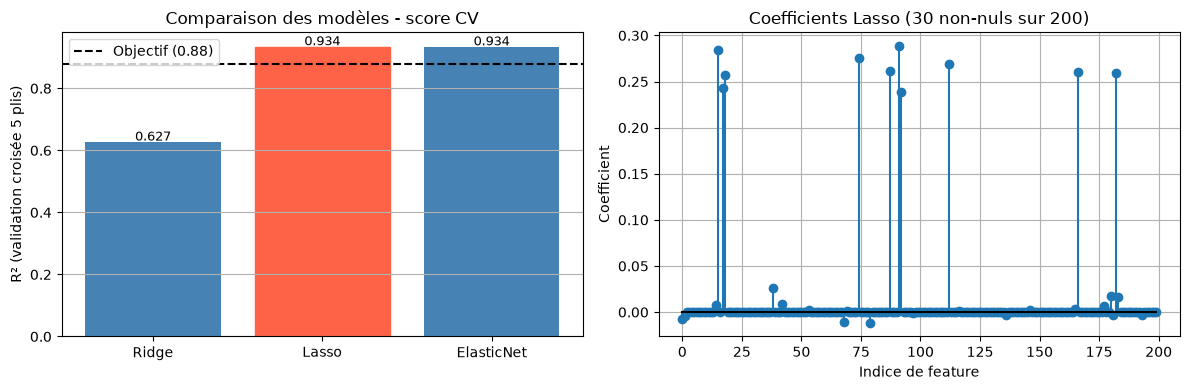

In [17]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import cross_val_score, KFold

kf5 = KFold(n_splits=5, shuffle=True, random_state=42)

# Scores de validation croisée aux alpha optimaux
cv_ridge = cross_val_score(Ridge(alpha=ridge.alpha_), X_train_s, y_train, cv=kf5, scoring='r2').mean()
cv_lasso = cross_val_score(Lasso(alpha=lasso.alpha_, max_iter=20_000), X_train_s, y_train, cv=kf5, scoring='r2').mean()
cv_enet  = cross_val_score(ElasticNet(alpha=enet.alpha_, l1_ratio=enet.l1_ratio_, max_iter=20_000), X_train_s, y_train, cv=kf5, scoring='r2').mean()

model_names  = ['Ridge', 'Lasso', 'ElasticNet']
cv_scores    = [cv_ridge, cv_lasso, cv_enet]
trained_models = [ridge, lasso, enet]

# Sélection par CV uniquement
best_idx  = int(np.argmax(cv_scores))
best_name = model_names[best_idx]
best_mod  = trained_models[best_idx]

print('Comparaison par score de validation croisée (5 plis) :')
print(f'{"Modèle":<15} {"CV R²":>10}')
print('-' * 27)
for nm, cv in zip(model_names, cv_scores):
    marker = ' <- sélectionné' if nm == best_name else ''
    print(f'{nm:<15} {cv:>10.4f}{marker}')

final_test_r2 = best_mod.score(X_test_s, y_test)
print(f'\nMeilleur modèle par CV : {best_name}')
print(f'R² test (évaluation finale, une seule fois) : {final_test_r2:.4f}')

# Graphique de comparaison (CV uniquement)
x = np.arange(len(model_names))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
bars = ax.bar(x, cv_scores, color=['steelblue']*len(model_names))
bars[best_idx].set_color('tomato')
ax.set_xticks(x); ax.set_xticklabels(model_names)
ax.set_ylabel('R² (validation croisée 5 plis)')
ax.set_title('Comparaison des modèles - score CV')
ax.axhline(0.88, color='k', ls='--', lw=1.5, label='Objectif (0.88)')
ax.legend(); ax.grid(axis='y')
for bar, cv in zip(bars, cv_scores):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{cv:.3f}', ha='center', fontsize=9)

# Coefficients Lasso
ax = axes[1]
ax.stem(range(200), lasso.coef_, markerfmt='C0o', linefmt='C0-', basefmt='k-')
ax.set_xlabel('Indice de feature')
ax.set_ylabel('Coefficient')
n_nonzero = np.sum(lasso.coef_ != 0)
ax.set_title(f'Coefficients Lasso ({n_nonzero} non-nuls sur 200)')
ax.grid(True)

plt.tight_layout()
plt.show()

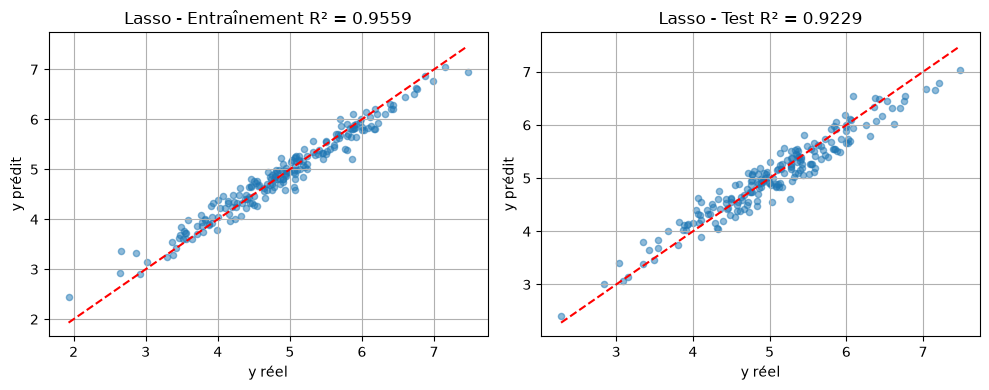

In [18]:
# Prédictions du meilleur modèle sélectionné par CV
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (X_s, y_true, label) in zip(axes, [
        (X_train_s, y_train, 'Entraînement'), (X_test_s, y_test, 'Test')]):
    y_pred = best_mod.predict(X_s)
    ax.scatter(y_true, y_pred, alpha=0.5, s=20)
    mn, mx = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5)
    ax.set_xlabel('y réel')
    ax.set_ylabel('y prédit')
    from sklearn.metrics import r2_score
    ax.set_title(f'{best_name} - {label} R² = {r2_score(y_true, y_pred):.4f}')
    ax.grid(True)

plt.tight_layout()
plt.show()

## Conclusion

### Ce que nous avons appris sur le dataset

Le dataset est particulier, il y a autant de features ($d = 200$) que d'observations ($n = 200$). Dans cette situation, une régression linéaire classique (OLS) mémoriserait parfaitement les données d'entraînement (train R² = 1.0) mais serait inutile sur de nouvelles données, c'est ce qu'on appelle le **surapprentissage**. C'est pourquoi la **régularisation** est indispensable ici.

### Comparaison des trois modèles

**Ridge (régularisation $L_2$)** : Ridge garde toutes les 200 features, mais réduit leurs coefficients. Le problème ici est que beaucoup de ces features ne sont pas utiles (elles n'ont pas de lien avec la cible). Ridge les garde quand même, ce qui introduit du bruit. Résultat : score de validation croisée modéré (~0.63), loin derrière les autres.

**Lasso (régularisation $L_1$)** : Lasso va plus loin, il force automatiquement les coefficients inutiles à **exactement zéro**. Il a ainsi détecté que seulement **~30 features sur 200** sont vraiment informatives, en ignorant les 170 autres. C'est cette capacité à "faire le tri" qui explique ses très bonnes performances (CV R² ~0.93).

**ElasticNet (mélange $L_1 + L_2$)** : ElasticNet combine les deux pénalités. Ici, l'optimisation a trouvé que la meilleure combinaison est `l1_ratio = 1.0`, ce qui signifie qu'ElasticNet se comporte exactement comme Lasso. Les deux modèles donnent donc des performances très similaires.

### Modèle sélectionné et évaluation finale

Le meilleur modèle est choisi **uniquement d'après le score de validation croisée** calculé sur l'ensemble d'entraînement, sans jamais regarder l'ensemble de test pendant cette étape. C'est une règle importante : si on compare les modèles sur le test set, il perd son caractère "neutre" et on ne peut plus faire confiance à l'estimation d'erreur finale.
Une fois le meilleur modèle choisi par CV, on l'évalue une seule fois sur l'ensemble de test pour avoir une estimation honnête de l'erreur de généralisation. Le score test obtenu (R² ~0.92) confirme que le modèle généralise bien à de nouvelles données.

### Pourquoi Lasso fonctionne si bien ?

Ce résultat confirme que **seul un petit nombre de features contient vraiment de l'information utile**,les 170 autres ne sont que du bruit. Lasso est conçu précisément pour détecter cela, il met automatiquement à zéro les features inutiles, ce qui lui permet de se concentrer sur ce qui compte vraiment. Dans un problème où $d = n$, cette sélection automatique est ce qui sauve le modèle du surapprentissage.